Single Decision Tree Accuracy: 0.8111111111111111
Bagging Classifier Accuracy: 0.8622222222222222


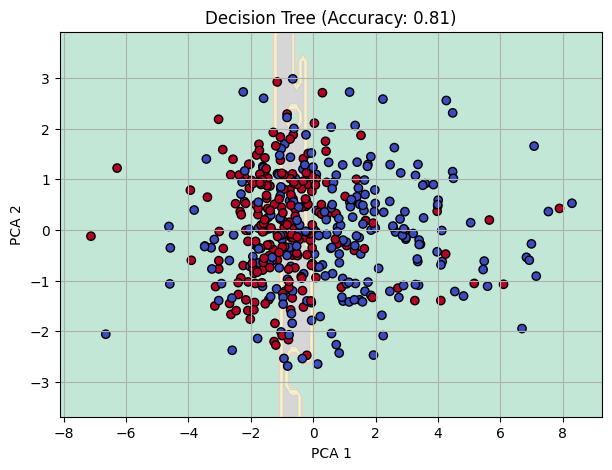

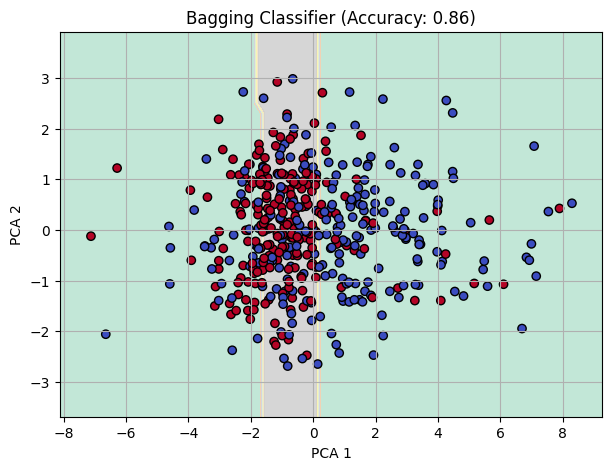

'Output -\nSingle Decision Tree Accuracy: 0.8111111111111111\nBagging Classifier Accuracy: 0.8622222222222222\n'

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
# 1. Generate synthetic classification dataset
X, y = make_classification(
   n_samples=1500,
   n_features=20,
   n_informative=2,
   n_redundant=10,
   n_repeated=0,
   n_classes=2,
   n_clusters_per_class=1,
   flip_y=0.15,                # Add noise
   class_sep=0.5,              # Overlapping classes
   random_state=42
)
# 2. Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# 3. Train single shallow Decision Tree (high variance)
tree = DecisionTreeClassifier(random_state=0)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)
acc_tree = accuracy_score(y_test, y_pred_tree)
print("Single Decision Tree Accuracy:", acc_tree)
# 4. Train Bagging Classifier
bagging = BaggingClassifier(
   estimator=DecisionTreeClassifier(max_depth=3, random_state=0),
   n_estimators=50,
   max_samples=0.8,
   bootstrap=True,
   random_state=0
)
bagging.fit(X_train, y_train)
y_pred_bag = bagging.predict(X_test)
acc_bag = accuracy_score(y_test, y_pred_bag)
print("Bagging Classifier Accuracy:", acc_bag)
# 5. PCA to reduce for visualization
pca = PCA(n_components=2)
X_vis = pca.fit_transform(X_test)
# 6. Plot decision boundaries
def plot_decision_boundary(model, X_raw, X_vis, y, title):
   h = 0.2
   x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
   y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
   xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                        np.arange(y_min, y_max, h))
   grid = np.c_[xx.ravel(), yy.ravel()]
   inv_grid = pca.inverse_transform(grid)
   Z = model.predict(inv_grid)
   Z = Z.reshape(xx.shape)

   plt.figure(figsize=(7, 5))
   plt.contourf(xx, yy, Z, cmap=plt.cm.Pastel2, alpha=0.8)
   plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolor='k')
   plt.title(title)
   plt.xlabel("PCA 1")
   plt.ylabel("PCA 2")
   plt.grid(True)
   plt.show()
# 7. Plot results
plot_decision_boundary(tree, X_test, X_vis, y_test, f"Decision Tree (Accuracy: {acc_tree:.2f})")
plot_decision_boundary(bagging, X_test, X_vis, y_test, f"Bagging Classifier (Accuracy: {acc_bag:.2f})")
'''Output -
Single Decision Tree Accuracy: 0.8111111111111111
Bagging Classifier Accuracy: 0.8622222222222222
'''